# Projektin Nimi (TBD)

Tony Karlin, Onni Kivinen, Joni Heikkilä, Jarkko Kärki

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import geopandas as gpd

from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from scripts.plot_functions import plot_accidents_by_year, plot_seriousness_by_year, plot_map, plot_accidents_by_place, accidents_by_place

## 1.0 Business understanding

### 1.1 Johdanto

Projektin tarkoituksena on tutkia Helsingin alueen liikenneonnettomuuksia. Liikenneonnettomuudet ovat usein erittäin vältettävissä, vaikkakin monesti onnettomuudet johtuvat inhimillisistä syistä kuten väsymyksestä, ylinopeudesta tai rattijuopumuksesta. Onnettomuuksissa vaanii myös toinen puoli, mikä ei ole aina yksilöiden käsissä. Nämä tekijät ovat niin sanottuja **taustariskejä** eli ympäristöön liittyviä riskejä.

Tässä työssä analysoimme tietoaineistoa vuosien 2000-2024 onnettomuuksista Helsingin eri osa-alueilla. Aineistolla pyrimme  tunnistamaan, esiintyykö onnettomuuksissa alueellisia keskittymiä, jolloin Helsingin Kaupunki voisi esimerkiksi tutkia, millaisia taustariskejä niihin mahdollisesti liittyy esim. tien kunto, nopeusalueet, heikko jalankulkijoiden näkyvyys.

### 1.2 Tavoite

Tavoitteena on selvittää tietoaineiston avulla seuraavat seikat:
- Missä päin kaupunkia on eniten onnettomuuksia?
- Mitkä onnettomuustyypit ovat yleisimpiä?
- Missä tapahtuu vakavimmat onnettomuudet?
- Ovatko onnettomuudet lisääntyneet vai vähentyneet vuosien ajan?
- Voidaanko onnettomuuden vakavuutta ennustaa sijainnin ja muiden muuttujien perusteella?

Näiden kysymyksien perusteella voitaisiin päätellä täytyykö alueiden taustariskitekijöitä tutkia.

### 1.3 Tutkimuskysymys

**Voiko liikenneonnettomuuden vakavuuden ennustaa sijainnin, onnettomuustyypin ja alueen perusteella?**

## 2.0 Data understanding

Päätietoainestona projektissa toimii [Liikenneonnettomuudet Helsingissä](https://avoindata.suomi.fi/data/fi/dataset/liikenneonnettomuudet-helsingissa/resource/0e396048-66ea-4b85-a1e3-2b387f29c378).

Tietoainesto sisältää Helsingissä tapahtuneiden liikenneottemuuksien tapahtumapaikat, vakavuustasteet ja onnettomuuslajit vuodesta 2000 alkaen.
Aineistoon lisätään [Helsingin piirijako](https://hri.fi/data/fi/dataset/helsingin-piirijako) aineistosta _"Osa-alue"_ ominaisuus.

- Tietoaineistot liitetään myöhemmin toisiinsa kartoittamalla aineistojen koordinaatit oikeisiin _Osa-alueisiin_.


In [25]:
geodata_filepath = "datasets/piirialuejako-1995-2019.gpkg"
areas = gpd.read_file(geodata_filepath, layer="osa_alue_2019")

accidents_filepath = "datasets/liikenneonnettomuudet.csv"
project_df = pd.read_csv(accidents_filepath, sep=";", decimal=",")

print("Datasetin rivien määrä:", len(project_df))
project_df.head()

Datasetin rivien määrä: 53800


,LAJI,pohj_etrs,ita_etrs,VAKAV_A,VV
0,JK,6675786.73,25501661.91,1,2022
1,JK,6674533.32,25502790.94,2,2022
2,JK,6679536.47,25506837.81,2,2022
3,JK,6675297.68,25498807.13,2,2022
4,JK,6674924.21,25495525.13,2,2022


### Muuttujat
| Muuttuja  | Selitys             | Lisätiedot|
| --------- | ------------------- |---------|
| LAJI      | onnettomuustyyppi   |jk = jalankulkijaonnettomuus, pp = polkupyöräonnettomuus, mp = mopo/moottoripyöräonnettomuus, ma = moottoriajoneuvo-onnettomuus|
| pohj_etrs | pohjoiskoordinaatti |Pohjoiskoordinaatti ETRS-GK25-järjestelmässä|
| ita_etrs  | itäkoordinaatti     |Itäkoordinaatti ETRS-GK25-järjestelmässä|
| VAKAV_A   | vakavuus            |1 = omaisuusvahinko,  2 = loukkaantumiseen johtanut, 3 = kuolemaan johtanut|
| VV        | vuosi               | Vuosi jolloin onnettomuus tapahtunut|

In [26]:
project_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53800 entries, 0 to 53799
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LAJI       53800 non-null  str  
 1   pohj_etrs  53797 non-null  str  
 2   ita_etrs   53797 non-null  str  
 3   VAKAV_A    53800 non-null  int64
 4   VV         53800 non-null  int64
dtypes: int64(2), str(3)
memory usage: 2.1 MB


### 2.1 Data visualisointi

Aineiston visualisoinnissa tarkastellaan kuinka paljon vuosittain sattuu onnettomuuksia onnettomuustyypin ja vakavuuksia vuosien mukaan. Aineisto kattaa neljä onnettomuustyyppiä: jalankulkijaonnettomuudet (JK), polkupyörä- (PP), mopo- ,moottoripyörä- (MP) ja moottoriajoneuvo-onnettomuudet (MA). Lisäksi tarkastellaan onnettomuuksien vakavuutta kolmessa luokassa: omaisuusvahinko (1), loukkaantuminen (2) ja kuolema (3).

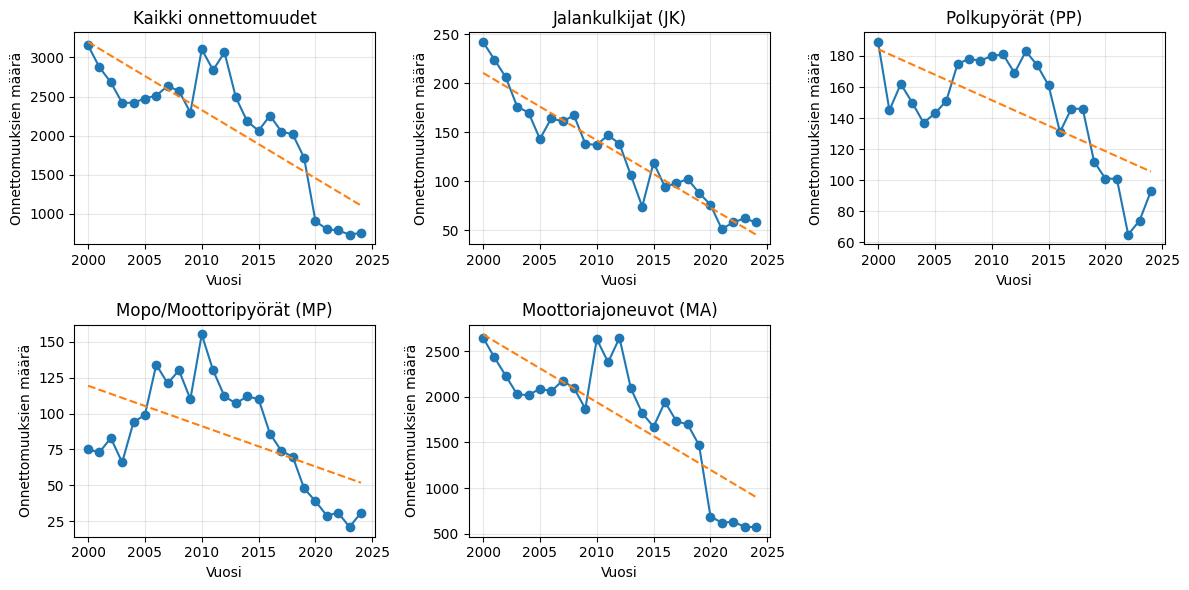

In [27]:
plot_accidents_by_year(project_df)

Onnettomuuksien kokonaismäärä on laskenut merkittävästi vuoden 2000 (3155) ja 2019 (1718) välillä.
Moottoriajoneuvo-onnettomuudet (MA) ovat selvästi yleisin tyyppi kattaen noin 80-85% kaikista tapauksista.
Polkupyöräonnettomuudet (PP) ovat pysyneet suhteellisen vakaina muihin tyyppeihin verrattuna, kun taas
mopo/moottoripyöräonnettomuudet (MP) kasvoivat 2005-2010 ja ovat sen jälkeen laskeneet voimakkaasti.

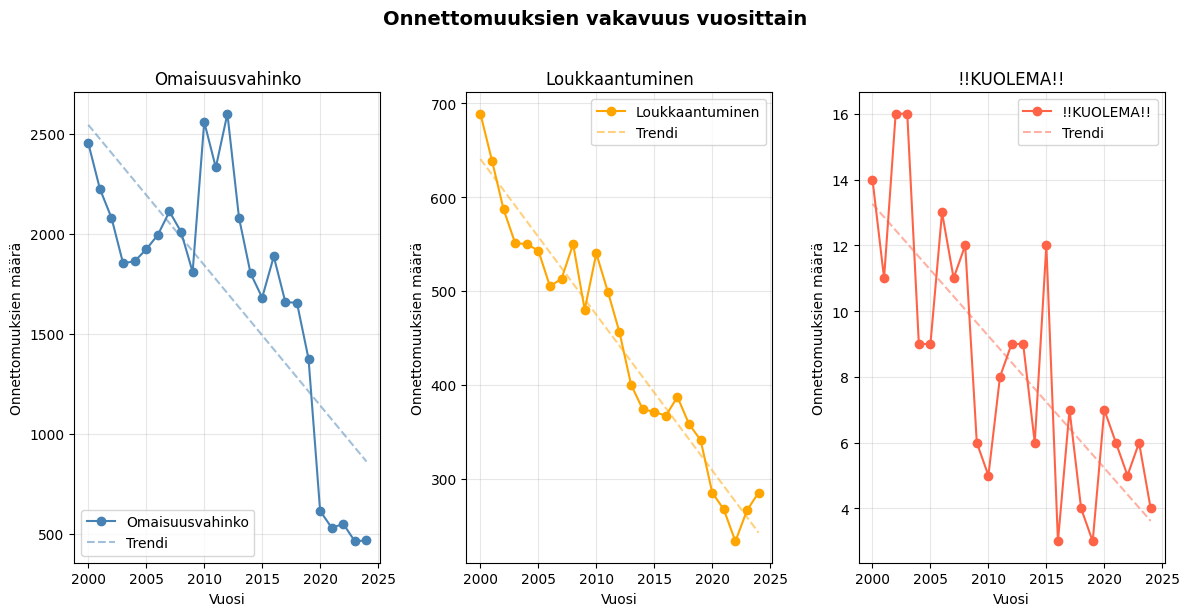

In [28]:
plot_seriousness_by_year(project_df)

Omaisuusvahinko-onnettomuudet ovat selvästi yleisin vakavuusluokka kattaen noin 75-80% kaikista tapauksista,
ja ne ovat laskeneet tasaisesti 2452:sta (2000) 1374:ään (2019).
Loukkaantumiseen johtaneet onnettomuudet ovat myös laskeneet 689:stä (2000) 341:een (2019).
Kuolemaan johtaneita onnettomuuksia on vuosittain erittäin vähän (3-16 tapausta),
ja niissä on myös havaittavissa laskeva trendi.

## 3.0 Data preparation

Poistetaan puutteelliset rivit. Tämän jälkeen yhdistetään piirialuejako datasettiin.

In [32]:
rows_before = len(project_df)
project_df = project_df.dropna()
rows_after = len(project_df)

print(f"Pudotettiin {rows_before - rows_after} riviä.")

Pudotettiin 3 riviä.


Seuraavaksi yhdistetään piirialuejakotieto alkuperäiselle dataframelle erillisestä ``piirialuejako-1995-2019.gpkg`` tiedostosta. Tavoitteena lisätä siis kaupunginosa-sarake jokaiselle datariville, jotta voidaan nähdä suoraan mihin kaupunginosaan mikäkin datarivi sijoittuu.

In [33]:
accidents = gpd.GeoDataFrame(
    project_df,
    geometry=gpd.points_from_xy(project_df["ita_etrs"], project_df["pohj_etrs"]),
    crs="EPSG:3879"
)
areas = areas.to_crs(accidents.crs)

accidents = gpd.sjoin(
    accidents,
    areas[["Nimi", "geometry"]],
    how="left",
    predicate="within"
)

accidents = accidents.rename(columns={"Nimi": "Osa-alue"})
accidents = accidents.drop(columns=["geometry", "index_right"])

Uudelleennimetään ja uudelleenjärjestetään sarakkeet selkeyden vuoksi.

In [34]:
col_rename = {"LAJI": "O_Tyyppi", "pohj_etrs": "Pohj_coords", "ita_etrs": "Itä_coords","VAKAV_A": "Vakavuus", "VV": "Vuosi"}
accidents = accidents.rename(columns=col_rename)
accidents = accidents.iloc[:, [1, 2, 5, 0, 4, 3]]
accidents

,Pohj_coords,Itä_coords,Osa-alue,O_Tyyppi,Vuosi,Vakavuus
0,6675786.73,25501661.91,Länsi-Hertto,JK,2022,1
1,6674533.32,25502790.94,Yliskylä,JK,2022,2
2,6679536.47,25506837.81,Mellunmäki,JK,2022,2
3,6675297.68,25498807.13,Kalasatama,JK,2022,2
4,6674924.21,25495525.13,Taka-Töölö,JK,2022,2
...,...,...,...,...,...,...
53795,6674696.29,25497044.46,Linjat,PP,2024,2
53796,6675329.91,25497183.32,Vallila,PP,2024,1
53797,6675746.02,25494119.16,Pikku Huopal,PP,2024,1
53798,6678387.52,25494869.15,Kivihaka,PP,2024,1


Nyt nähdään ETRS-GK25 (EPSG 3879) koordinaatiston kautta lisätyt kaupunginosatiedot on nyt yhdistetty taulukkoon.

Muutetaan data-arvot kategorisiksi/numeerisiksi arvoiksi, jotta niitä voidaan myöhemmin käyttää mallissa.

In [35]:
print(accidents.dtypes)

Pohj_coords      str
Itä_coords       str
Osa-alue         str
O_Tyyppi         str
Vuosi          int64
Vakavuus       int64
dtype: object


In [36]:
cols_to_categorical = ["Osa-alue", "O_Tyyppi"]
accidents[cols_to_categorical] = accidents[cols_to_categorical].astype("category")

cols_to_float = ["Pohj_coords", "Itä_coords"]
accidents[cols_to_float] = accidents[cols_to_float].astype(float)

Tarkistetaan setin datatyypit.

In [37]:
print(accidents.dtypes)

Pohj_coords     float64
Itä_coords      float64
Osa-alue       category
O_Tyyppi       category
Vuosi             int64
Vakavuus          int64
dtype: object


Viimeiseksi poistetaan vuodet 2019 jälkeen, koska avoindata.suomi.fi-sivuston mukaan data päivitettiin viimeksi 15. tammikuuta 2020, joten vuoden 2020 jälkeiset tiedot voivat olla puutteellisia tai virheellisiä.

In [38]:
accidents = accidents[accidents["Vuosi"] <= 2019]

In [39]:
accidents.describe(include='all')

,Pohj_coords,Itä_coords,Osa-alue,O_Tyyppi,Vuosi,Vakavuus
count,4.981900e+04,4.981900e+04,49809,49819,49819.000000,49819.000000
unique,NaN,NaN,140,4,NaN,NaN
top,NaN,NaN,Kamppi,MA,NaN,NaN
freq,NaN,NaN,3087,41746,NaN,NaN
mean,6.676551e+06,2.549789e+07,NaN,NaN,2008.933620,1.202051
std,3.494570e+03,3.636920e+03,NaN,NaN,5.633834,0.410581
min,6.670495e+06,2.549076e+07,NaN,NaN,2000.000000,1.000000
25%,6.673281e+06,2.549564e+07,NaN,NaN,2004.000000,1.000000
50%,6.675890e+06,2.549699e+07,NaN,NaN,2009.000000,1.000000
75%,6.679402e+06,2.549983e+07,NaN,NaN,2013.000000,1.000000


## 4.0 Modeling

Käytetään Random Forest -mallia, jonka avulla pyritään ennustamaan onnettomuuden vakavuutta käyttäen sijaintia, kaupunginosaa ja onnettomuustyyppiä.

### 4.1 Feature preparation

Muutetaan kategoriset muuttujat one-hot-encodauksella numeeriseen muotoon, jotta malli voi käyttää sitä.

In [40]:
model_df = accidents.copy()
model_df = pd.get_dummies(
    model_df,
    columns=["Osa-alue", "O_Tyyppi"]
)

### 4.2 Feature ja target muuttujat

In [41]:
X = model_df.drop("Vakavuus", axis=1)
y = model_df["Vakavuus"]

### 4.3 Train-test split

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### 4.4 Random Forest -mallin koulutus

In [43]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=3,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

## 5.0 Evaluation

Arvioidaan mallin suorituskykyä.

In [44]:
y_pred = rf_model.predict(X_test)

In [45]:
accuracy = accuracy_score(y_test, y_pred)
print("Mallin tarkkuus:", accuracy)
confusion_matrix(y_test, y_pred)

Mallin tarkkuus: 0.8259735046166198


array([[7457,  473,   86],
       [ 900,  760,  250],
       [  11,   14,   13]])

Tarkkuus huomataan pyörivän **70-80 %** välillä, koska suurin osa onnettomuuksista kuuluu vakavuusluokkaan 1.

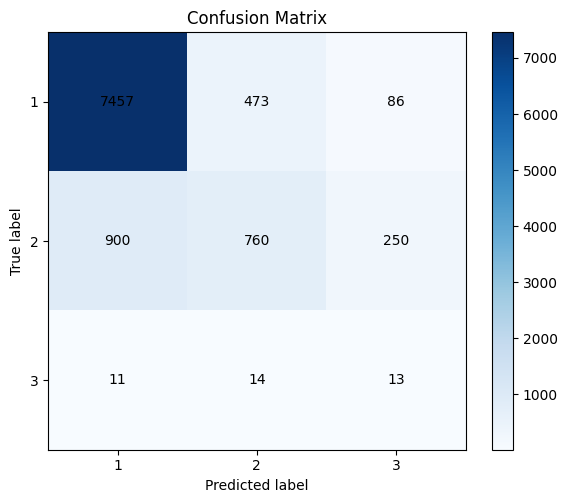

In [46]:
cm = confusion_matrix(y_test, y_pred)
labels = np.unique(np.concatenate([y_test.values, y_pred]))

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(labels))
plt.xticks(tick_marks, labels)
plt.yticks(tick_marks, labels)
plt.xlabel("Predicted label")
plt.ylabel("True label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

## 6.0 Deployment